# EasyMLP Demo Notebook

This notebook builds a small synthetic regression problem, trains `EasyMLP`, and visualizes the goodness of fit.

The example uses:

- one positive and globally increasing output
- one bounded output in `[0, 1]` with partial monotonicity
- automatic train/validation split and hidden fine-tuning
- fit diagnostics through scatter plots, residual histograms, and a monotonic slice plot


## Environment note

This notebook expects `numpy`, `torch`, and `matplotlib` in the active Python environment. The core `EasyMLP` module does not require `matplotlib`, but the visualization cells below do.

In [1]:
import importlib.util
from pathlib import Path

import numpy as np

if importlib.util.find_spec("matplotlib") is None:
    raise ImportError(
        "This demo notebook uses matplotlib for visualization. "
        "Install it in your current environment first, for example with `conda install matplotlib` or `pip install matplotlib`."
    )

import matplotlib.pyplot as plt

from easymlp import EasyMLP

plt.style.use("ggplot")
np.set_printoptions(precision=4, suppress=True)

print("Working directory:", Path.cwd())

Working directory: /Users/tianhaozhao/Desktop/test-MLP-codex


/opt/miniconda3/envs/sbert_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
rng = np.random.default_rng(123)
n_samples = 900

X = rng.uniform(0.0, 1.0, size=(n_samples, 2)).astype(np.float32)
x0 = X[:, 0]
x1 = X[:, 1]

# Output 0: strictly positive and increasing in both x0 and x1.
y0 = np.exp(0.9 * x0 + 0.6 * x1) + 0.03 * rng.normal(size=n_samples)
y0 = np.clip(y0, 1e-4, None)

# Output 1: lives in [0, 1], decreases in x0 and increases in x1.
latent = -1.7 * x0 + 2.3 * x1 + 0.3 * np.sin(2.0 * np.pi * x1)
y1 = 1.0 / (1.0 + np.exp(-latent))
y1 = np.clip(y1 + 0.01 * rng.normal(size=n_samples), 0.0, 1.0)

Y = np.column_stack([y0, y1]).astype(np.float32)

print("X shape:", X.shape)
print("Y shape:", Y.shape)
print("y0 range:", float(y0.min()), float(y0.max()))
print("y1 range:", float(y1.min()), float(y1.max()))

X shape: (900, 2)
Y shape: (900, 2)
y0 range: 0.9959484599522923 4.3430270347612
y1 range: 0.1639184216850752 0.8992921053647951


In [3]:
model = EasyMLP(
    in_dim=2,
    out_dim=2,
    hidden_dims=[128, 64, 32],
    activations=["Softplus", "Tanh", "Sigmoid"],
    out_spaces=["positive", "[0,1]"],
    monotonicity=[
        [1, 1],
        [-1, 1],
    ],
    advanced_options={
        "max_epochs": 220,
        "patience": 30,
        "batch_size": 64,
        "fine_tune_epochs": 25,
        "trace_every": 20,
    },
)

model.train(
    x=X,
    y=Y,
    random_seed=42,
    show_trace=True,
    gpu_acceleration="cuda",
    l2_regularization=True,
)

model.summary()

EasyMLP Summary
  trained           : True
  input dimension   : 2
  output dimension  : 2
  hidden dims       : [128, 64, 32]
  activations       : ['Softplus', 'Tanh', 'Sigmoid']
  output spaces     : ['positive', '[0,1]']
  monotonicity      : [[1, 1], [-1, 1]]
  parameters        : 21506
  random seed       : 42
  device            : cpu
  mse               : 0.004262
  mae               : 0.045652
  r2                : 0.983137
  n samples         : 900
  train/val split   : 720/180
  best epoch        : 220
  best val loss     : 0.025506
  training seconds  : 5.764
  L1/L2 regularized : False/True
  architecture:
    _VectorMLP(
  (subnets): ModuleList(
    (0-1): 2 x _PartiallyMonotoneScalarNet(
      (first_linear): _InputPartiallyMonotoneLinear()
      (tail_linears): ModuleList(
        (0-2): 3 x _PositiveLinear()
      )
      (activations): ModuleList(
        (0): Softplus(beta=1.0, threshold=20.0)
        (1): Tanh()
        (2): Sigmoid()
      )
    )
  )
)


"EasyMLP Summary\n  trained           : True\n  input dimension   : 2\n  output dimension  : 2\n  hidden dims       : [128, 64, 32]\n  activations       : ['Softplus', 'Tanh', 'Sigmoid']\n  output spaces     : ['positive', '[0,1]']\n  monotonicity      : [[1, 1], [-1, 1]]\n  parameters        : 21506\n  random seed       : 42\n  device            : cpu\n  mse               : 0.004262\n  mae               : 0.045652\n  r2                : 0.983137\n  n samples         : 900\n  train/val split   : 720/180\n  best epoch        : 220\n  best val loss     : 0.025506\n  training seconds  : 5.764\n  L1/L2 regularized : False/True\n  architecture:\n    _VectorMLP(\n  (subnets): ModuleList(\n    (0-1): 2 x _PartiallyMonotoneScalarNet(\n      (first_linear): _InputPartiallyMonotoneLinear()\n      (tail_linears): ModuleList(\n        (0-2): 3 x _PositiveLinear()\n      )\n      (activations): ModuleList(\n        (0): Softplus(beta=1.0, threshold=20.0)\n        (1): Tanh()\n        (2): Sigmoid()

In [4]:
fitted = model.fitted()
residual = model.residual()

mse = np.mean((Y - fitted) ** 2, axis=0)
mae = np.mean(np.abs(Y - fitted), axis=0)
ss_res = np.sum((Y - fitted) ** 2, axis=0)
ss_tot = np.sum((Y - Y.mean(axis=0, keepdims=True)) ** 2, axis=0)
r2 = 1.0 - ss_res / ss_tot

for j in range(Y.shape[1]):
    print(f"output {j}: mse={mse[j]:.6f}, mae={mae[j]:.6f}, r2={r2[j]:.6f}")

output 0: mse=0.006722, mae=0.058575, r2=0.986057
output 1: mse=0.001802, mae=0.032730, r2=0.922981


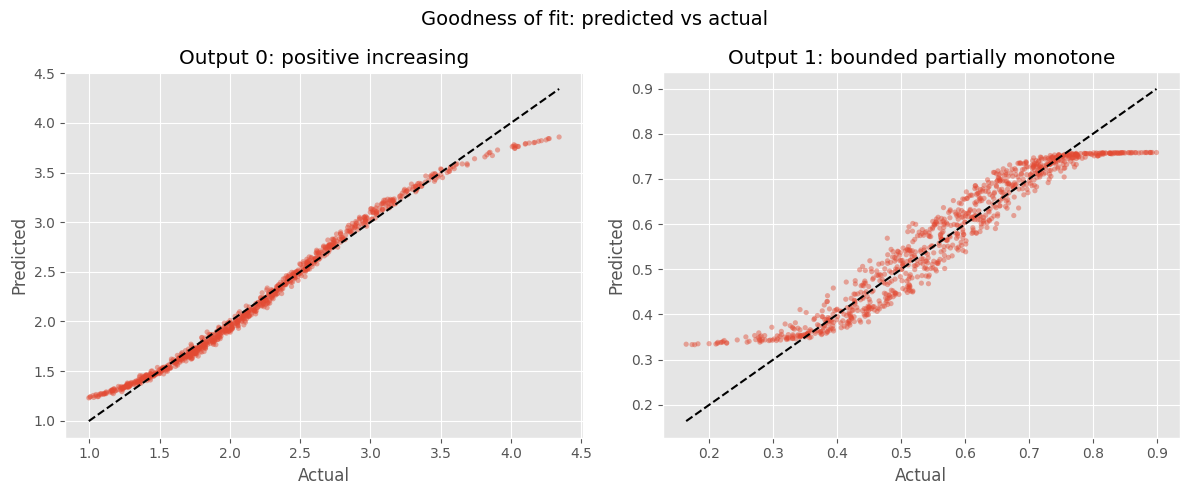

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

labels = ["Output 0: positive increasing", "Output 1: bounded partially monotone"]
for j, ax in enumerate(axes):
    ax.scatter(Y[:, j], fitted[:, j], s=14, alpha=0.45, edgecolors="none")
    lo = min(float(Y[:, j].min()), float(fitted[:, j].min()))
    hi = max(float(Y[:, j].max()), float(fitted[:, j].max()))
    ax.plot([lo, hi], [lo, hi], linestyle="--", linewidth=1.5, color="black")
    ax.set_title(labels[j])
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")

fig.suptitle("Goodness of fit: predicted vs actual", fontsize=14)
fig.tight_layout()
plt.show()

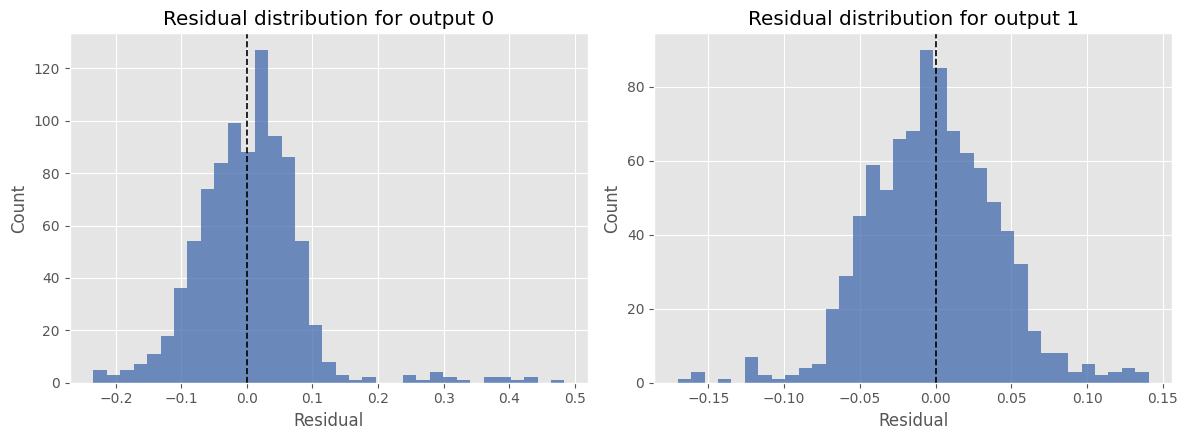

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for j, ax in enumerate(axes):
    ax.hist(residual[:, j], bins=35, alpha=0.8, color="#4C72B0")
    ax.axvline(0.0, color="black", linestyle="--", linewidth=1.2)
    ax.set_title(f"Residual distribution for output {j}")
    ax.set_xlabel("Residual")
    ax.set_ylabel("Count")

fig.tight_layout()
plt.show()

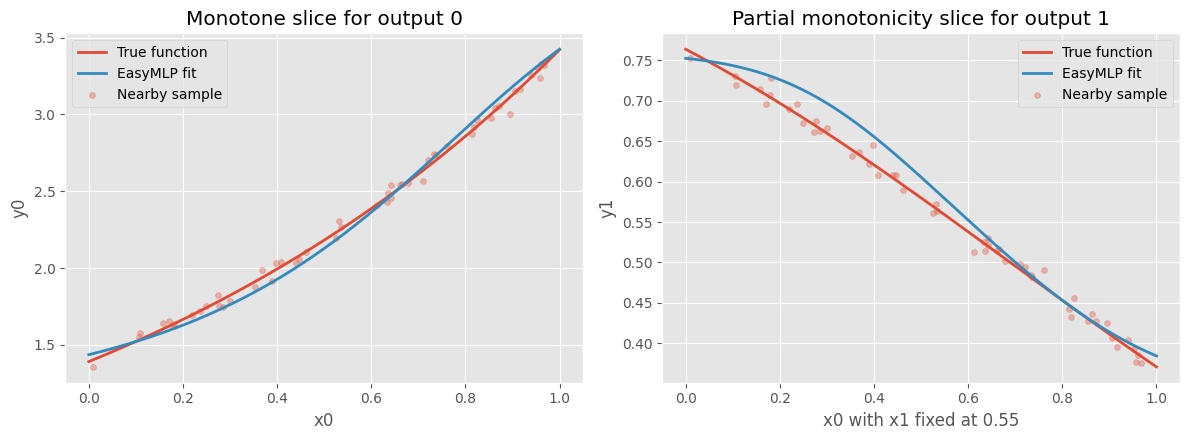

In [7]:
grid = np.linspace(0.0, 1.0, 250, dtype=np.float32)
fixed_x1 = 0.55
slice_points = np.column_stack([grid, np.full_like(grid, fixed_x1)]).astype(np.float32)

pred_slice = model(slice_points)
true_slice_y0 = np.exp(0.9 * grid + 0.6 * fixed_x1)
true_slice_y1 = 1.0 / (1.0 + np.exp(-(-1.7 * grid + 2.3 * fixed_x1 + 0.3 * np.sin(2.0 * np.pi * fixed_x1))))

mask = np.abs(X[:, 1] - fixed_x1) < 0.03

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(grid, true_slice_y0, label="True function", linewidth=2.0)
axes[0].plot(grid, pred_slice[:, 0], label="EasyMLP fit", linewidth=2.0)
axes[0].scatter(X[mask, 0], Y[mask, 0], s=18, alpha=0.35, label="Nearby sample")
axes[0].set_title("Monotone slice for output 0")
axes[0].set_xlabel("x0")
axes[0].set_ylabel("y0")
axes[0].legend()

axes[1].plot(grid, true_slice_y1, label="True function", linewidth=2.0)
axes[1].plot(grid, pred_slice[:, 1], label="EasyMLP fit", linewidth=2.0)
axes[1].scatter(X[mask, 0], Y[mask, 1], s=18, alpha=0.35, label="Nearby sample")
axes[1].set_title("Partial monotonicity slice for output 1")
axes[1].set_xlabel("x0 with x1 fixed at 0.55")
axes[1].set_ylabel("y1")
axes[1].legend()

fig.tight_layout()
plt.show()

In [8]:
probe = np.array([0.35, 0.55], dtype=np.float32)
print("Probe point:", probe)
print("Prediction:", model(probe))
print("Jacobian:\n", model.jacobian(probe))

hessians = model.hessian(probe)
for idx, h in enumerate(hessians):
    print(f"Hessian for output {idx}:\n{h}\n")

Probe point: [0.35 0.55]
Prediction: [1.8399 0.6775]
Jacobian:
 [[ 1.6494  1.1655]
 [-0.4151  0.4048]]
Hessian for output 0:
[[3.4097 2.2278]
 [2.2278 1.7736]]

Hessian for output 1:
[[-1.1131  1.1043]
 [ 1.1043 -1.0516]]

